<a href="https://colab.research.google.com/github/harishmuh/Python-for-Data-Science-Analysis/blob/main/Statistical_description_and_normality_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction to Statistics**

Previously, we learned that statistics is the study of collecting, analyzing, and interpreting data. Today, humans generate and collect more data than ever before. Every time we send a text message, make an online purchase, or post a photo on social media, we generate new data. As the amount of data increases, so does the need to analyze and interpret it. This is a key reason why statistics and data-driven work are so important. Therefore, the field of data analysis is growing almost as rapidly as data itself.

Data professionals use statistics to analyze data in business, medicine, science, engineering, government, and more. Data professionals use the power of statistical methods to identify meaningful patterns and find relationships in data, analyze and quantify uncertainty, generate insights from data, make accurate predictions about the future, and solve complex problems.

Even if we haven't studied statistics, we probably use statistics every day. For example, we start our day by checking the weather online, where we learn that there is a 70 percent chance of rain or a 50 percent chance of snow. Perhaps we visit a sports website to learn about our favorite baseball player's batting average or basketball player's scoring average. In a news app, we might find an election poll that reports a three percent margin of error and notes that an online survey was used to collect the data. Or perhaps we are a parent, and when we take our child for a routine checkup, we learn that their height and weight fall within certain percentiles. When we ask for more information, the doctor shows us the median height and weight for all children the same age. These scenarios involve statistical concepts that we will learn more about.

___

In [ ]:
# data manipulation
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# statistics
import statsmodels.api as sm

## **1. Descriptive Statistics**

Descriptive statistics describe or summarize the main features of a data set. Descriptive statistics are very useful because they allow us to quickly understand large amounts of data. For example, let's say we have data on the heights of 10 million people. We probably don't want to scan through 10 million rows of data to analyze it for our report. Even if we did, it would be difficult to interpret the data. However, if we summarize the data, we can quickly make it meaningful. Finding the average height gives us useful insight into the data, and reading a summary is much more enjoyable than staring at millions of rows of data.

In general, descriptive statistics involves analyzing data through graphs and tables and calculating various descriptive measures such as the mean, variance, percentiles, and others through numerical summaries.

### **a. Numerical Summary**

There are two main types of numerical summaries:
- **Measures of Central Tendency**
- **Measures of Spread**.

In [ ]:
# Loading dataset
url = 'https://raw.githubusercontent.com/harishmuh/Python-for-Data-Science-Analysis/refs/heads/main/datasets/bestsellers%20with%20categories.csv'
df_books = pd.read_csv(url)
df_books

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


#### `Measures of Central Tendency`

This summary describes the central position of the frequency distribution for a set of data. We can describe it using, for example, the `Mean` or average, the `Median` or middle value, or the `Mode` or most frequently occurring value.

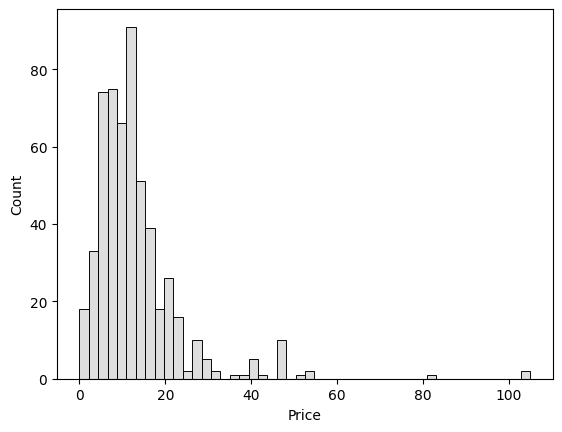

In [ ]:
sns.histplot(df_books['Price'], color='lightgray')
plt.show()

**Mean**

The sum of the observed values in a set of data divided by the number of observations. The mean is the most commonly used measure of center for quantitative variables. The mean is an appropriate measure of center for quantitative variables that are **normally distributed**.

$$ \bar{x} = \frac{\sum_{i=1}^n x_i}{n} $$

In [ ]:
mean_x = df_books['Price'].mean()
mean_x

np.float64(13.1)

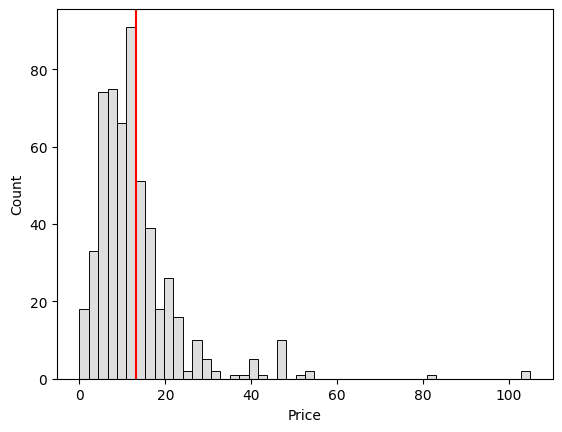

In [ ]:
sns.histplot(df_books['Price'], color='lightgray')
plt.axvline(x=mean_x, color='red')
plt.show()

**Median**

The median is the middle value in a sorted list.

In [ ]:
median_x = df_books['Price'].median()
median_x

11.0

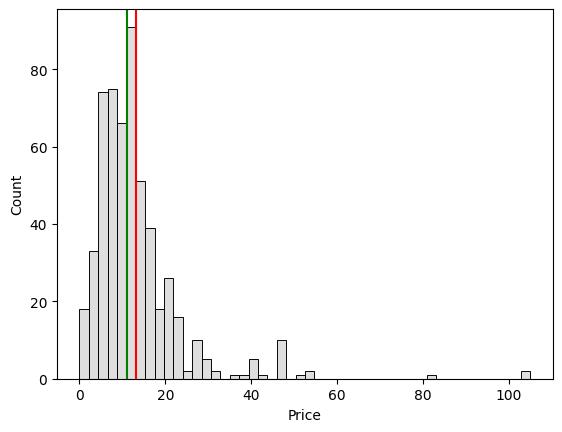

In [ ]:
sns.histplot(df_books['Price'], color='lightgray')
plt.axvline(x=mean_x, color='red')
plt.axvline(x=median_x, color='green')
plt.show()

The median is a good choice if the quantitative variable has a skewed or non-normal distribution. We avoid using the mean in cases of skewed distributions, as the mean can be heavily influenced by extreme data or outliers.

`Case 1 - without outlier data`

In [ ]:
cluster_price1 = [300, 400, 400, 500, 500, 500, 600, 600, 700]

print('Mean cluster_price1:', np.mean(cluster_price1))
print('Median cluster_price1:', np.median(cluster_price1))

Mean cluster_price1: 500.0
Median cluster_price1: 500.0


`Case 2 - with outlier data`

In [ ]:
cluster_price = [300, 400, 400, 500, 500, 500, 600, 600, 700000]

print('Mean cluster_price:', np.mean(cluster_price))
print('Median cluster_price:', np.median(cluster_price))

Mean cluster_price: 78200.0
Median cluster_price: 500.0


**Mode**

The mode is the value of a qualitative or quantitative variable calculated from the value that appears most frequently or has the highest frequency. The mode should be used when calculating measures of central tendency for qualitative variables such as gender, car brand, domicile, educational background, and so on.

In [ ]:
mode_x = df_books['Price'].mode()[0]
mode_x

np.int64(8)

In [ ]:
mode_genre = df_books['Genre'].mode()[0]
mode_genre

'Non Fiction'

#### `Measures of Spread`

Measuring the spread or variation of data is another important aspect of descriptive studies. Two datasets of the same variable may have the same center point, but their data variability may differ. The most frequently used measures of variation are the range, the interquartile range, or the distance between the 1st and 3rd quartiles, and the standard deviation.

**Range**

Range is the difference between the largest and smallest data points, or the maximum value minus the minimum value. However, be careful, as range is very sensitive, meaning its values are easily influenced by extreme values.

$$ Range = x_{max} - x_{min}$$



In [ ]:
max_price = df_books['Price'].max()
min_price = df_books['Price'].min()
Range =  max_price - min_price
Range

105

**Standard Deviation**

Standard deviation is the most frequently used measure of variability. Simply put, standard deviation is the average absolute deviation from the mean. Deviation itself is the difference between each data point and its mean.

The formula for standard deviation can be seen in the following figure.
$$ s = \sqrt{\frac{\sum_{i=1}^n (x_i-\bar{x})^2}{n-1}} $$

If you use the mean as the center point of the data, then standard deviation is the best choice for measuring data variability. The greater the variation in our data, the larger the standard deviation value will be. Standard deviation is sensitive to the presence of extreme values (outliers).

In [ ]:
std_x = df_books['Price'].std()
std_x

10.84226197842238

**Percentile**

A percentile is a value that divides data sorted from smallest to largest into 100 equal parts. For example, a student's percentile score is 75% out of 100 students, meaning their score is higher than 74 other students.

In [ ]:
pct_75 = df_books['Price'].quantile(0.75)
pct_75
# From the entire list of books we have, 75% are priced below or equal to 16.

np.float64(16.0)

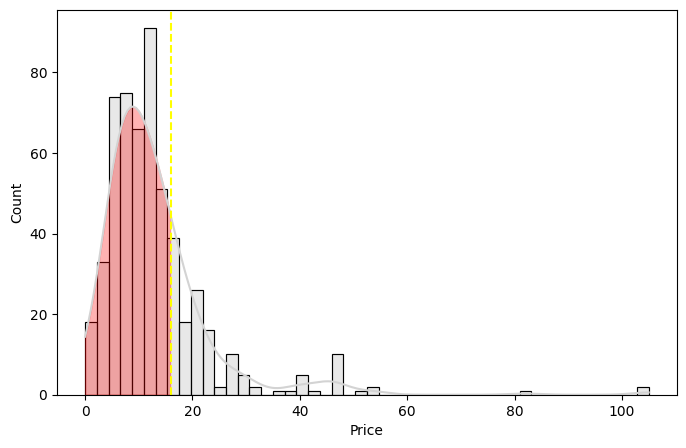

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(
    data=df_books['Price'],
    kde=True,
    color='lightgrey'
)

kde_x, kde_y = ax.lines[0].get_data()

ax.axvline(
    x=pct_75,
    color="yellow",
    linestyle='--'
)

ax.fill_between(
    kde_x,
    kde_y,
    where=(kde_x < pct_75),
    color='red',
    alpha=0.3
)

plt.show()

**Quartiles**

Quartiles are a special form of percentiles. The first quartile, or Q1, is the 25th percentile, or 25 percent. The second quartile, or Q2, is the 50th percentile, or 50 percent, equal to the median. Finally, the third quartile, or Q3, is the 75th percentile, or 75 percent.

In [ ]:
Q1 = df_books['Price'].quantile(0.25)
Q2 = df_books['Price'].quantile(0.5)
Q3 = df_books['Price'].quantile(0.75)

print('Quartile 1:', Q1)
print('Quartile 2 (Median):', Q2)
print('Quartile 3:', Q3)

Quartile 1: 7.0
Quartile 2 (Median): 11.0
Quartile 3: 16.0


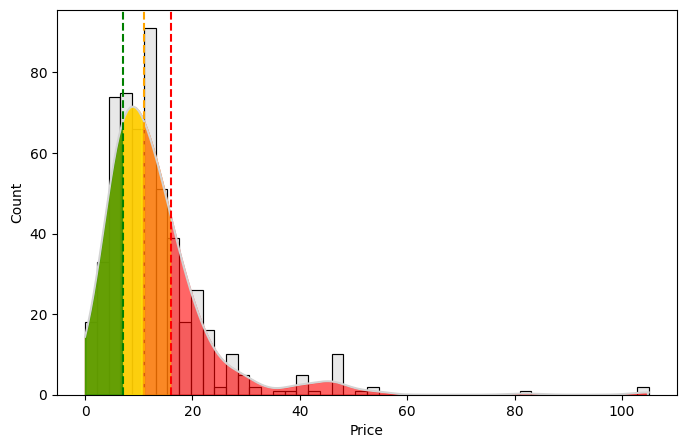

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(
    data=df_books['Price'],
    kde=True,
    color='lightgrey'
)

kde_x, kde_y = ax.lines[0].get_data()

ax.axvline(
    x=Q1,
    color="green",
    linestyle='--'
)

ax.axvline(
    x=Q2,
    color="orange",
    linestyle='--'
)

ax.axvline(
    x=Q3,
    color="red",
    linestyle='--'
)

ax.fill_between(
    kde_x,
    kde_y,
    where=(kde_x < df_books['Price'].max()),
    color='red',
    alpha=0.6
)

ax.fill_between(
    kde_x,
    kde_y,
    where=(kde_x < Q3),
    color='orange',
    alpha=0.6
)

ax.fill_between(
    kde_x,
    kde_y,
    where=(kde_x < Q2),
    color='yellow',
    alpha=0.6
)

ax.fill_between(
    kde_x,
    kde_y,
    where=(kde_x < Q1),
    color='green',
    alpha=0.6
)


plt.show()

**IQR**

The interquartile range is the distance between Q1 and Q3. Therefore, the formula is

$$ IQR = Q_3 - Q_1$$

In [ ]:
# lower quartile
Q1 = df_books['Price'].quantile(0.25)

# upper quartile
Q3 = df_books['Price'].quantile(0.75)

# inter quartile range
IQR = Q3 - Q1

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)

Q1: 7.0
Q3: 16.0
IQR: 9.0


The IQR can be used as a substitute for the standard deviation when data is not normally distributed, as the standard deviation is very sensitive to outliers. The IQR is often used to detect potential outliers. A data point is considered an outlier if its value is:
- below $Q_1 - 1.5 * IQR$, or
- above $Q_3 + 1.5 * IQR$

In [ ]:
outlier_lower_limit = Q1 - 1.5 * IQR
outlier_upper_limit = Q3 + 1.5 * IQR

print('Outlier Lower Limit:', outlier_lower_limit)
print('Outlier Upper Limit:', outlier_upper_limit)

# So, book prices above 29.5 can be considered outliers.

Outlier Lower Limit: -6.5
Outlier Upper Limit: 29.5


We can calculate the number of outliers as follows:

In [ ]:
lower_limit_outliers = df_books[df_books['Price'] < outlier_lower_limit]
upper_limit_outliers = df_books[df_books['Price'] > outlier_upper_limit]

print('Number of lower limit outliers:', len(lower_limit_outliers))
print('Number of upper limit outliers:', len(upper_limit_outliers))

print('Number of outliers:', len(lower_limit_outliers) + len(upper_limit_outliers))

Number of lower limit outliers: 0
Number of upper limit outliers: 31
Number of outliers: 31


### **b. Table Summary**

The table summary can be a results table:

- value_counts
- groupby
- pivot_table
- crosstab

**value_counts()**

- Number of books by genre

In [ ]:
df_books['Genre'].value_counts().to_frame()

,count
Genre,
Non Fiction,310
Fiction,240


**group_by()**

- Average and median book prices by year of publication

In [ ]:
df_books.groupby('Year')[['Price']].agg(['mean', 'median']).reset_index()

Year  Price       
           mean median
0   2009  15.40   12.0
1   2010  13.48   12.5
2   2011  15.10   13.0
3   2012  15.30   13.0
4   2013  14.60   12.5
5   2014  14.64   10.0
6   2015  10.42    9.0
7   2016  13.18    9.0
8   2017  11.38    9.0
9   2018  10.52    8.0
10  2019  10.08   10.0

**pivot_table()**

- Number of books each year by genre

In [ ]:
df_books.pivot_table(
    index='Genre',
    columns='Year',
    values='Name',
    aggfunc = len,
    margins=True,
    margins_name='Total'
)

Year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,Total
Genre,,,,,,,,,,,,
Fiction,24,20,21,21,24,29,17,19,24,21,20,240
Non Fiction,26,30,29,29,26,21,33,31,26,29,30,310
Total,50,50,50,50,50,50,50,50,50,50,50,550


**pd.crosstab()**

- Proportion of books in each year by genre

In [ ]:
pd.crosstab(
    index=df_books['Genre'],
    columns=df_books['Year'],
    values=df_books['Name'],
    aggfunc='count',
    normalize='columns',
    margins=True
)

Year,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,All
Genre,,,,,,,,,,,,
Fiction,0.48,0.4,0.42,0.42,0.48,0.58,0.34,0.38,0.48,0.42,0.4,0.436364
Non Fiction,0.52,0.6,0.58,0.58,0.52,0.42,0.66,0.62,0.52,0.58,0.6,0.563636


## **2. Normal Distribution**

The normal distribution is also known as the Gaussian distribution. The normal distribution is widely discussed in inferential statistics topics. It is also an assumption in several machine learning algorithms.

The normal distribution has a bell-shaped data distribution curve. The curve is symmetrical, with the center point at the mean (μ), and the data spread out by standard deviations (σ) more near the mean.

![Normal Distribution Curve](https://brilliantbimbel.com/wp-content/uploads/2022/12/1_IdGgdrY_n_9_YfkaCh-dag.png)

Many dependent variables are generally assumed to be normally distributed in the population. If a variable is assumed to be normally distributed, we can draw conclusions or inferences about its values. Some data cleaning techniques and machine learning algorithms require the assumption that the data is normally distributed.

Visually, a normal distribution can be analyzed from its median and mean values. These three histograms reflect the condition of the data distribution.

![Mean vs Median](https://upload.wikimedia.org/wikipedia/commons/thumb/c/cc/Relationship_between_mean_and_median_under_different_skewness.png/434px-Relationship_between_mean_and_median_under_different_skewness.png)

The histogram in the middle shows that the mean is equal to the median, or a symmetrical/normal distribution. The histograms on the left and right indicate a non-normal distribution. In the left histogram, the distribution is skewed to the right. The median is smaller than the mean. The majority of the data is skewed toward the smallest value. Meanwhile, the graph on the right shows a distribution that is skewed to the left. The majority of the data is skewed toward the largest value. The median is greater than the mean.

A normal distribution can also be analyzed from its standard deviation value. If the data distribution is bell-shaped or normally distributed, then approximately:
- 68% of the data lies within +/- 1 standard deviation of the mean
- 95% of the data lies within +/- 2 standard deviations of the mean
- 99.7% of the data lies within +/- 3 standard deviations of the mean

![Normal Distribution](https://www.sentrakaliindustri.com/wp-content/uploads/2024/01/Pentingnya-Distribusi-Normal-dalam-Analisis-Data.jpg)

There are many methods for testing whether a variable is normally distributed. We can use various methods to test for data normality.
- First, with graphical visualizations, we can use histograms, box plots, and Q-Q plots.
- Second, with frequentist tests, including the Kolmogorov-Smirnov test, the Lilliefors test, the Shapiro-Wilk test, and the D'Agostino & Pearson test.

### **a. Graphical Method**

#### `1. Histogram`

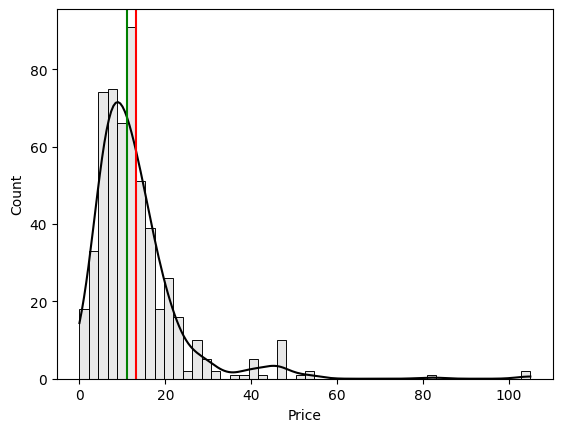

In [ ]:
ax = sns.histplot(df_books['Price'], color='lightgray', kde=True)
ax.lines[0].set_color('black')
plt.axvline(x=df_books['Price'].mean(), color='red')
plt.axvline(x=df_books['Price'].median(), color='green')
plt.show()

The `Price` column is not normally distributed but rather right-skewed (positively skewed). We will check several other attributes.

**Mean vs Median**

In [ ]:
df_books['Price'].mean() > df_books['Price'].median()

np.True_

A mean value greater than the median indicates the characteristics of right skewed or positive skewed data (not normally distributed).

**Standard Deviation**

In [ ]:
mean_price = df_books['Price'].mean()
std_price = df_books['Price'].std()

Now, let's calculate the actual percentage of book prices that fall within +/- 1 standard deviation of the mean.

In [ ]:
lower_limit  = mean_price - 1 * std_price
upper_limit  = mean_price + 1 * std_price

((df_books['Price']>=lower_limit) & (df_books['Price']<=upper_limit)).mean()

np.float64(0.88)

Now, let's calculate the actual percentage of book prices that fall within +/- 2 standard deviations of the mean.

In [ ]:
lower_limit = mean_price - 2 * std_price
upper_limit = mean_price + 2 * std_price

((df_books['Price']>=lower_limit) & (df_books['Price']<=upper_limit)).mean()

np.float64(0.9563636363636364)

Now, let's calculate the actual percentage of book prices that fall within +/- 3 standard deviations of the mean.

In [ ]:
lower_limit  = mean_price - 3 * std_price
upper_limit  = mean_price + 3 * std_price

((df_books['Price']>=lower_limit) & (df_books['Price']<=upper_limit)).mean()

np.float64(0.9709090909090909)

The values we obtained of 88%, 95.6%, and 97% are quite far from the empirical values, namely: around 68%, 95%, and 99.7%.

**Skewness**

In statistics, skewness is a measure of the asymmetry of the probability distribution of a random variable about its mean. In other words, skewness indicates the magnitude and direction of skewness (deviation from horizontal symmetry). The skewness value is obtained from the following formula:

$$ skewness = \frac{\frac{1}{n}\sum_{i=1}^n (x_i-\bar{x})^3}{(\frac{1}{n}\sum_{i=1}^n (x_i-\bar{x})^2)^{3/2}} $$

The skewness value can be positive or negative, or even undefined. If the skewness is 0, then the data is perfectly symmetric, although this is unlikely for real-world data. As a general rule of thumb:

- If the skewness is less than -1 or greater than 1, the distribution is highly skewed.

- If the skewness is between -1 and -0.5 or between 0.5 and 1, the distribution is slightly skewed.
- If the skewness is between -0.5 and 0.5, the distribution is approximately symmetric.

In [ ]:
df_books['Price'].skew()

np.float64(3.685056537836339)

The skewness has a positive value indicating the characteristics of right skewed or positive skewed data (not normally distributed).

**Kurtosis**

Kurtosis tells you the height and sharpness of the central peak, relative to a normal distribution. Kurtosis can be calculated using the following formula:

Kurtosis = \frac{\frac{1}{n}\sum_{i=1}^n (x_i-\bar{x})^3}{(\frac{1}{n}\sum_{i=1}^n (x_i-\bar{x})^2)^2} - 3

As a general rule of thumb:
- if kurtosis is less than 3, the distribution is platy kurtic (sloping)
- if kurtosis is equal to 3, the distribution is normal
- if kurtosis is greater than 3, the distribution is leptokurtic (sloping)

In [ ]:
df_books['Price'].kurtosis()

np.float64(22.43352032785043)

Kurtosis of more than 3 indicates the characteristics of leptokurtic data (not normally distributed)

#### `2. Boxplot`

A boxplot is a graphical summary of a sample distribution that can illustrate the shape of the data distribution (skewness), measures of central tendency, and measures of dispersion (diversity) in the observed data.

There are five statistical measures that can be read from a boxplot:

- `minimum value`: the smallest observed value
- `Q1`: the lowest or first quartile
- `Q2`: the median or middle value
- `Q3`: the highest or third quartile
- `maximum value`: the largest observed value.

Furthermore, a boxplot can also indicate the presence or absence of `outliers` and `extreme` values in the observed data.

![Boxplot](https://help.ezbiocloud.net/wp-content/uploads/2020/04/%E1%84%89%E1%85%B3%E1%84%8F%E1%85%B3%E1%84%85%E1%85%B5%E1%86%AB%E1%84%89%E1%85%A3%E1%86%BA-2020-04-19-%E1%84%8B%E1%85%A9%E1%84%8C%E1%85%A5%E1%86%AB-9.41.35.png)

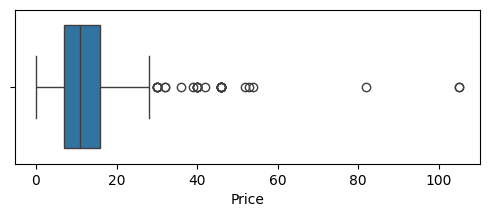

In [ ]:
# Boxplot
plt.figure(figsize=(6,2))
sns.boxplot(x=df_books['Price'])
plt.show()

A longer upper whisker indicates a right-skewed variable (not normally distributed).

In [ ]:
inlier = df_books[(df_books['Price']>=outlier_lower_limit) & (df_books['Price']<=outlier_upper_limit)]
inlier.head()

min_inlier = inlier['Price'].min()
max_inlier = inlier['Price'].max()

In [ ]:
print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Outlier Lower Limit:', outlier_lower_limit)
print('Outlier Upper Limit:', outlier_upper_limit)
print("Inlier Minimum Value:", min_inlier)
print("Inlier Maximum Value:", max_inlier)

Q1: 7.0
Q3: 16.0
IQR: 9.0
Outlier Lower Limit: -6.5
Outlier Upper Limit: 29.5
Inlier Minimum Value: 0
Inlier Maximum Value: 28


#### 3. Q-Q Plot

A Q-Q Plot is a graph that compares the empirical quantiles of a data distribution with the expected quantiles of a normal distribution. Quantiles are values that divide the data distribution into specific fractions. In a Q-Q Plot, the x-axis (horizontal) represents the expected quantiles of the normal distribution, while the y-axis (vertical) represents the empirical quantiles of the actual data.

Here are some things related to how to read a Q-Q Plot:

- `Diagonal Line`: **If the points in a Q-Q Plot follow the diagonal line, this indicates that the data roughly follows a normal distribution**. The closer the points are to the diagonal line, the better the distribution is normal.
- `Deviation from the Diagonal Line`: **If the points deviate from the diagonal line, this indicates non-normality in the data distribution**. If the points move upwards, the data distribution may be tail-heavy (leptokurtic), while if they move downwards, the data distribution may be flatter (platykurtic).
- `S-shaped or J-shaped pattern`: **If the Q-Q Plot forms an S-shaped or J-shaped pattern, this indicates that the data distribution has a sharp increase or decrease in the tails**, which can be an indication of abnormality.

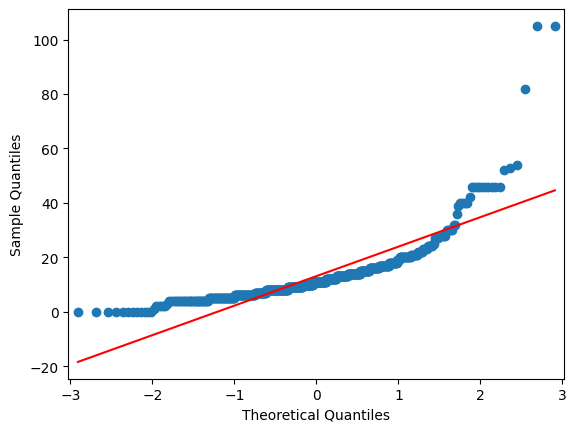

In [ ]:
sm.qqplot(data=df_books['Price'], line='s')
plt.show()

### **b. Frequentist Test/Normality Test**

In statistics, a normality test is used to determine whether a data set is well modeled by a normal distribution and to calculate how likely it is that the underlying random variables in the dataset are normally distributed. The following are the hypotheses for a normality test:

- $H_0$: Data is normally distributed
- $H_1$: Data is NOT normally distributed

A decision regarding a hypothesis can be made by comparing the probability value (p-value) from the test to the significance level α (μ). The following are the decision-making rules based on the probability value approach:

- If the probability value > the significance level, then $H_0$ fails to reject, meaning we assume the data are normally distributed.
- If the probability value < the significance level, then $H_0$ is rejected, meaning we assume the data are NOT normally distributed.

A commonly used significance level (α) is 5% or 0.05.

#### `1. Kolmogorov-Smirnov`

The Kolmogorov-Smirnov test calculates the distance between the empirical distribution and the theoretical distribution. This test is well-known but has several shortcomings. The Kolmogorov-Smirnov test requires large data sets and is sensitive to outliers.

Decision-making regarding a hypothesis can be done by comparing the Dmax value from the test to the Dcritical value. The following is a decision-making rule based on the probability value approach.

- If the Dmax value < Dcritical, then $H_0$ fails to be rejected, meaning we assume the data is normally distributed.
- If the Dmax value > Dcritical, then $H_0$ is rejected, meaning we assume the data is NOT normally distributed.

##### **How to Manually Calculate the Normality Test with the Kolmogorov-Smirnov Test**

The following is the data from the Data Science program class.

In [ ]:
data = pd.DataFrame({
'name': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P'],
'value': [40, 50, 50, 60, 60, 60, 70, 70, 70, 70, 80, 80, 80, 90, 90, 100]
})

data.head()

,name,value
0,A,40
1,B,50
2,C,50
3,D,60
4,E,60


The Kolmogorov-Smirnov test approach will be used to test the hypothesis of whether the data is drawn from a normally distributed population (for example, using a significance level of 𝛼 = 5%). Calculations will be performed manually.

**Mean and Standard Deviation Calculation**

In [ ]:
mean = data['value'].mean()
standard_deviation = data['value'].std()

print('Mean:', mean)
print('Standard Deviation:', standard_deviation)

Mean: 70.0
Standard Deviation: 16.32993161855452


**Calculating the probability of $X_i$ or $f(X_i)$**

The probability for the value $X=40$ or $f(40)$ is $\frac{1}{16}=0.0625$ and so on (see table below)

In [ ]:
# Create a table containing values and frequencies
tabulation = data['value'].value_counts(sort=False).to_frame().reset_index().rename(columns={'index':'value', 'count':'Frequency'})

# Calculate the probability for value x
tabulation['f(X)'] = tabulation['Frequency'] / tabulation['Frequency'].sum()
tabulation

,value,Frequency,f(X)
0,40,1,0.0625
1,50,2,0.1250
2,60,3,0.1875
3,70,4,0.2500
4,80,3,0.1875
5,90,2,0.1250
6,100,1,0.0625


**Calculating the cumulative probability of $X_i$ or $F(X_i)=f(X\leq X_i)$**

- The value of $F(40) = 0.0625$.
- The value of $F(50) = f(x \leq 50) = f(40) + f(50) = 0.0625 +0.125 = 0.1875$ and so on.

In [ ]:
tabulation['F(X)'] = tabulation['f(X)'].cumsum()
tabulation

,value,Frequency,f(X),F(X)
0,40,1,0.0625,0.0625
1,50,2,0.1250,0.1875
2,60,3,0.1875,0.3750
3,70,4,0.2500,0.6250
4,80,3,0.1875,0.8125
5,90,2,0.1250,0.9375
6,100,1,0.0625,1.0000


**Transform the $X_i$ values into standardized normal $Z_i$ values**

Next, transform the $X_i$ values into standardized normal $Z_i$ values calculated using the formula

$$Z_i=\frac{X_i-\bar{X}}{s}$$

For $X=40$, then
$$Z(X=40)=\frac{40-70}{16.330}=-1.837$$

For $X=50$, then
$$Z(X=50)=\frac{50-70}{16.330}=-1.2247$$

In [ ]:
tabulation['Z'] = tabulation['value'].apply(lambda x: (x-mean)/standard_deviation)
tabulation

,value,Frequency,f(X),F(X),Z
0,40,1,0.0625,0.0625,-1.837117
1,50,2,0.1250,0.1875,-1.224745
2,60,3,0.1875,0.3750,-0.612372
3,70,4,0.2500,0.6250,0.000000
4,80,3,0.1875,0.8125,0.612372
5,90,2,0.1250,0.9375,1.224745
6,100,1,0.0625,1.0000,1.837117


**Transform the $X_i$ values into standardized normal $Z_i$ values**

Next, transform the $X_i$ values into standardized normal $Z_i$ values calculated using the formula

$$Z_i=\frac{X_i-\bar{X}}{s}$$

For $X=40$, then
$$Z(X=40)=\frac{40-70}{16.330}=-1.837$$

For $X=50$, then
$$Z(X=50)=\frac{50-70}{16.330}=-1.2247$$

In [ ]:
import scipy.stats

tabulation['F(Z)'] = tabulation['Z'].apply(lambda x: scipy.stats.norm.cdf(x))
tabulation

,value,Frequency,f(X),F(X),Z,F(Z)
0,40,1,0.0625,0.0625,-1.837117,0.033096
1,50,2,0.1250,0.1875,-1.224745,0.110336
2,60,3,0.1875,0.3750,-0.612372,0.270146
3,70,4,0.2500,0.6250,0.000000,0.500000
4,80,3,0.1875,0.8125,0.612372,0.729854
5,90,2,0.1250,0.9375,1.224745,0.889664
6,100,1,0.0625,1.0000,1.837117,0.966904


**Calculating the absolute value of the difference between $F(Z_i)$ and $F(X_i)$**

Next, calculate the absolute value of the difference between $F(Z_i)$ and $F(X_i)$.

$$D_i = |F(Z_i) − F(X_i)|$$

- The value of $D$ for $X = 40$ is $|0.033 − 0.0625| = 0.0295$
- The value of $D$ for $X = 50$ is $|0.110 − 0.1875| = 0.077$,
- and so on.

In [ ]:
tabulation['D'] = np.abs(tabulation['F(X)'] - tabulation['F(Z)'])
tabulation

,value,Frequency,f(X),F(X),Z,F(Z),D
0,40,1,0.0625,0.0625,-1.837117,0.033096,0.029404
1,50,2,0.1250,0.1875,-1.224745,0.110336,0.077164
2,60,3,0.1875,0.3750,-0.612372,0.270146,0.104854
3,70,4,0.2500,0.6250,0.000000,0.500000,0.125000
4,80,3,0.1875,0.8125,0.612372,0.729854,0.082646
5,90,2,0.1250,0.9375,1.224745,0.889664,0.047836
6,100,1,0.0625,1.0000,1.837117,0.966904,0.033096


**Calculating the statistical value of the Kolmogorov-Smirnov test $D_{max}$**

The statistical value of the Kolmogorov-Smirnov test is the largest or maximum D value. Based on the above, the largest D value is 0.125, so the statistical value of the Kolmogorov-Smirnov test is 0.125, or $D_{max}$ = 0.125.

In [ ]:
Dmax = tabulation['D'].max()
Dmax

0.125

**Calculating the Kolmogorov-Smirnov critical value**

The Kolmogorov-Smirnov critical value at a 5% significance level and a sample size of 16 based on the Kolmogorov-Smirnov distribution table is 0.328.

![Kolmogorov-Smirnov Table](https://miro.medium.com/v2/resize:fit:828/format:webp/1*FobhWb-Dm9IZruroK6-3uQ.png)

**Decision-making regarding the hypothesis.**

Note that because the statistical value of the Kolmogorov-Smirnov test (0.125) is smaller than the Kolmogorov-Smirnov critical value (0.328), the null hypothesis is rejected. Therefore, the assumption that the data science values above are drawn from a normally distributed population can be accepted at the 5% significance level.

##### **How to Calculate the Kolmogorov-Smirnov Test in Python**

Manually calculating the normality test using the Kolmogorov-Smirnov test is very easy in Python. We'll reuse the df_books data.

In [ ]:
from scipy.stats import kstest

stat, pvalue = kstest(df_books['Price'], 'norm')
alpha = 0.05

if pvalue > alpha:
  print(f'pvalue = {pvalue}. pvalue > {alpha}. Fail to Reject Ho. We can assume that the data is normally distributed')
else:
  print(f'pvalue = {pvalue}. pvalue < {alpha}. Reject Ho. We can assume that the data is NOT normally distributed')

pvalue = 0.0. pvalue < 0.05. Reject Ho. We can assume that the data is NOT normally distributed


#### 2. Lilliefors Test

The Lilliefors test is based on the KS test. The difference with the Lilliefors test is that the mean and variance of the population distribution can be estimated rather than predetermined by the user.

Therefore, the Lilliefors test uses the Lilliefors distribution rather than the Kolmogorov distribution. Although the Lilliefors test is an improvement on the KS test, its power is still lower than that of the Shapiro-Wilk test.

In [ ]:
from statsmodels.stats.diagnostic import lilliefors

stat, pvalue = lilliefors(df_books['Price'])
alpha = 0.05

if pvalue > alpha:
  print(f'pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail to Reject Ho. We can assume that the data is normally distributed')
else:
  print(f'pvalue = {pvalue:.5f}. pvalue < {alpha}. Reject Ho. We can assume that the data is NOT normally distributed')

pvalue = 0.00100. pvalue < 0.05. Reject Ho. We can assume that the data is NOT normally distributed


#### `3. Shapiro-Wilk Test`

The Shapiro-Wilk test is widely considered the most powerful test for normal distribution. This test was developed specifically for the normal distribution and cannot be used to test other distributions.

In [ ]:
from scipy.stats import shapiro

stat, pvalue = shapiro(df_books['Price'])
alpha = 0.05

if pvalue > alpha:
  print(f'pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail to Reject Ho. We can assume that the data is normally distributed')
else:
  print(f'pvalue = {pvalue:.5f}. pvalue < {alpha}. Reject Ho. We can assume that the data is NOT normally distributed')

pvalue = 0.00000. pvalue < 0.05. Reject Ho. We can assume that the data is NOT normally distributed


#### `4. D'Agostino & Pearson Test`

The D'Agostino-Pearson test is based on the assumption that when data is normally distributed, the test statistic has a chi-square distribution with 2 degrees of freedom. The D'Agostino and Pearson tests combine skewness and kurtosis to produce a test of data normality.

In [ ]:
from scipy.stats import normaltest

stat, pvalue = normaltest(df_books['Price'])
alpha = 0.05

if pvalue > alpha:
  print(f'pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail to Reject Ho. We can assume that the data is normally distributed')
else:
  print(f'pvalue = {pvalue:.5f}. pvalue < {alpha}. Reject Ho. We can assume that the data is NOT normally distributed')

pvalue = 0.00000. pvalue < 0.05. Reject Ho. We can assume that the data is NOT normally distributed
